In [2]:
from statsmodels.datasets import get_rdataset
import pandas as pd

data = get_rdataset("AirPassengers").data
y = data["value"].values
     

Exploracion de datos:

In [3]:
data.head()

,time,value
0,1949.000000,112
1,1949.083333,118
2,1949.166667,132
3,1949.250000,129
4,1949.333333,121


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   time    144 non-null    float64
 1   value   144 non-null    int64  
dtypes: float64(1), int64(1)
memory usage: 2.4 KB


In [5]:
import pandas as pd

df = pd.DataFrame({
    "fecha": pd.date_range(
        start="1949-01-01",
        periods=len(y),
        freq="MS"
    ),
    "y": y
})

df = df.set_index("fecha")

In [6]:
import numpy as np

df["mes"] = df.index.month
df["trimestre"] = df.index.quarter
df["año"] = df.index.year
df["dia_año"] = df.index.dayofyear

df["mes_sin"] = np.sin(2 * np.pi * df["mes"] / 12)
df["mes_cos"] = np.cos(2 * np.pi * df["mes"] / 12)

df["dia_año_sin"] = np.sin(
    2 * np.pi * df["dia_año"] / 365.25
)
df["dia_año_cos"] = np.cos(
    2 * np.pi * df["dia_año"] / 365.25
)

In [7]:
for ventana in [3, 12]:
    serie_pasada = df["y"].shift(1)

    df[f"rolling_mean_{ventana}"] = (
        serie_pasada.rolling(ventana).mean()
    )
    df[f"rolling_std_{ventana}"] = (
        serie_pasada.rolling(ventana).std()
    )
    df[f"rolling_max_{ventana}"] = (
        serie_pasada.rolling(ventana).max()
    )
    df[f"rolling_min_{ventana}"] = (
        serie_pasada.rolling(ventana).min()
    )

In [8]:
df["expanding_mean"] = (
    df["y"].shift(1).expanding().mean()
)

df["expanding_std"] = (
    df["y"].shift(1).expanding().std()
)

In [33]:
for lag in [1, 2, 3, 12]:
    df[f"lag_{lag}"] = df["y"].shift(lag)

In [34]:
features_fecha = [
    "mes",
    "trimestre",
    "año",
    "dia_año",
    "mes_sin",
    "mes_cos",
    "dia_año_sin",
    "dia_año_cos"
]

In [35]:
features_all = [
    columna
    for columna in df.columns
    if columna != "y"
]

In [36]:
df_modelo = df.dropna().copy()

In [37]:
train_temporal = df_modelo.iloc[:-24]
test_temporal = df_modelo.iloc[-24:]

In [38]:
from sklearn.model_selection import train_test_split

train_shuffle, test_shuffle = train_test_split(
    df_modelo,
    test_size=24,
    shuffle=True,
    random_state=42
)

In [39]:
from sklearn.ensemble import GradientBoostingRegressor

def entrenar_modelo(train, test, features):
    X_train = train[features]
    y_train = train["y"]

    X_test = test[features]
    y_test = test["y"]

    modelo = GradientBoostingRegressor(
        random_state=42
    )

    modelo.fit(X_train, y_train)
    predicciones = modelo.predict(X_test)

    return modelo, y_test, predicciones

In [40]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

def calcular_metricas(y_true, y_pred, y_train):
    mae = mean_absolute_error(y_true, y_pred)

    rmse = mean_squared_error(
        y_true,
        y_pred
    ) ** 0.5

    mape = (
        mean_absolute_percentage_error(
            y_true,
            y_pred
        ) * 100
    )

    error_naive = np.mean(
        np.abs(
            y_train.values[12:] -
            y_train.values[:-12]
        )
    )

    mase = mae / error_naive

    return {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape,
        "MASE": mase
    }

In [41]:
modelos = {}

modelos["fecha_temporal"], _, _ = entrenar_modelo(
    train_temporal, test_temporal, features_fecha
)

modelos["all_temporal"], _, _ = entrenar_modelo(
    train_temporal, test_temporal, features_all
)

modelos["fecha_shuffle"], _, _ = entrenar_modelo(
    train_shuffle, test_shuffle, features_fecha
)

modelos["all_shuffle"], _, _ = entrenar_modelo(
    train_shuffle, test_shuffle, features_all
)

In [42]:
modelo_all_temporal = modelos["all_temporal"]

In [43]:
modelos = {}
resultados = {}

# Modelo con variables de fecha y separación temporal
modelo, y_test, predicciones = entrenar_modelo(
    train_temporal,
    test_temporal,
    features_fecha
)

modelos["fecha_temporal"] = modelo

resultados["fecha_temporal"] = calcular_metricas(
    y_test,
    predicciones,
    train_temporal["y"]
)


# Modelo con todas las variables y separación temporal
modelo, y_test, predicciones = entrenar_modelo(
    train_temporal,
    test_temporal,
    features_all
)

modelos["all_temporal"] = modelo

resultados["all_temporal"] = calcular_metricas(
    y_test,
    predicciones,
    train_temporal["y"]
)


# Modelo con variables de fecha y separación aleatoria
modelo, y_test, predicciones = entrenar_modelo(
    train_shuffle,
    test_shuffle,
    features_fecha
)

modelos["fecha_shuffle"] = modelo

resultados["fecha_shuffle"] = calcular_metricas(
    y_test,
    predicciones,
    train_shuffle["y"]
)


# Modelo con todas las variables y separación aleatoria
modelo, y_test, predicciones = entrenar_modelo(
    train_shuffle,
    test_shuffle,
    features_all
)

modelos["all_shuffle"] = modelo

resultados["all_shuffle"] = calcular_metricas(
    y_test,
    predicciones,
    train_shuffle["y"]
)

In [44]:
for nombre_modelo, metricas in resultados.items():

    print(f"\n----- {nombre_modelo} -----")
    print(f"MAE:  {metricas['MAE']:.4f}")
    print(f"RMSE: {metricas['RMSE']:.4f}")
    print(f"MAPE: {metricas['MAPE']:.4f}%")
    print(f"MASE: {metricas['MASE']:.4f}")


----- fecha_temporal -----
MAE:  72.2623
RMSE: 78.6916
MAPE: 15.7007%
MASE: 2.3676

----- all_temporal -----
MAE:  47.8954
RMSE: 58.2558
MAPE: 9.9243%
MASE: 1.5693

----- fecha_shuffle -----
MAE:  13.7334
RMSE: 18.5865
MAPE: 5.6511%
MASE: 0.1091

----- all_shuffle -----
MAE:  7.0475
RMSE: 8.6467
MAPE: 3.2741%
MASE: 0.0560


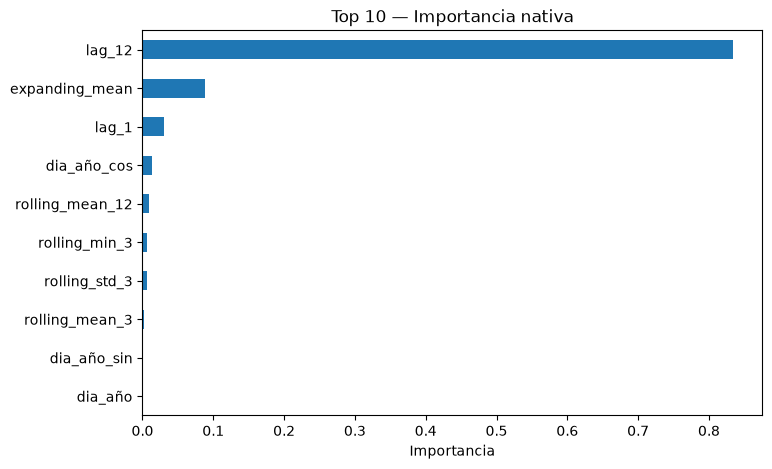

In [45]:
import pandas as pd
import matplotlib.pyplot as plt

importancia_nativa = pd.Series(
    modelo_all_temporal.feature_importances_,
    index=features_all
).sort_values(ascending=False)

importancia_nativa.head(10).sort_values().plot(
    kind="barh",
    figsize=(8, 5)
)

plt.title("Top 10 — Importancia nativa")
plt.xlabel("Importancia")
plt.show()

In [46]:
from sklearn.inspection import permutation_importance

resultado_perm = permutation_importance(
    modelo_all_temporal,
    test_temporal[features_all],
    test_temporal["y"],
    scoring="neg_mean_absolute_error",
    n_repeats=30,
    random_state=42
)

importancia_perm = pd.Series(
    resultado_perm.importances_mean,
    index=features_all
).sort_values(ascending=False)

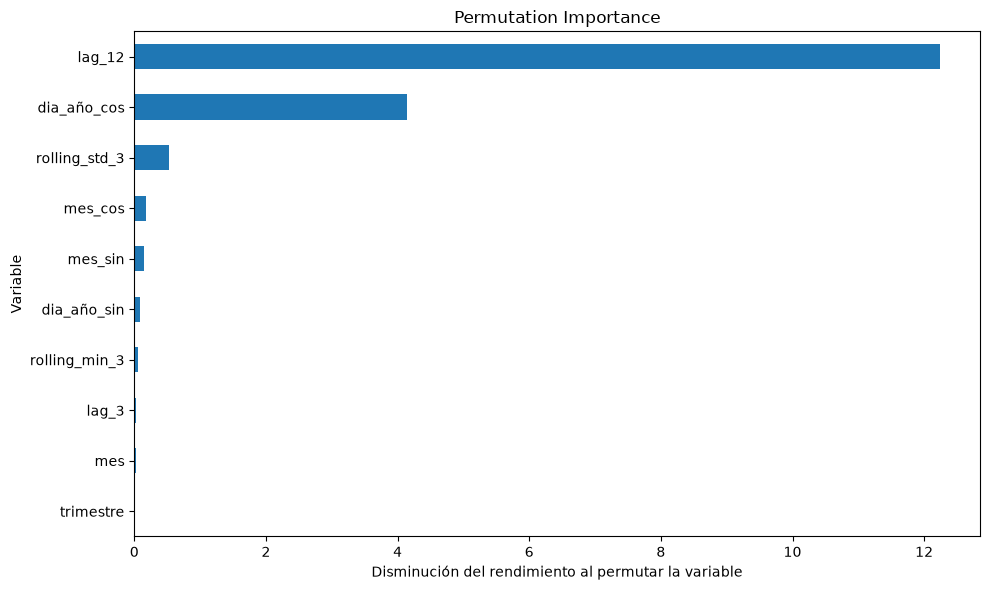

In [47]:
top_perm = importancia_perm.head(10).sort_values()

plt.figure(figsize=(10, 6))

top_perm.plot(kind="barh")

plt.title("Permutation Importance")
plt.xlabel("Disminución del rendimiento al permutar la variable")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

Normalizamos los valores de las "importancias" para compararlos 

In [48]:
importancia_nativa_norm = (
    importancia_nativa / importancia_nativa.sum()
)

importancia_perm_positiva = importancia_perm.clip(lower=0)

importancia_perm_norm = (
    importancia_perm_positiva / importancia_perm_positiva.sum()
)

In [49]:
comparacion_importancias = pd.DataFrame({
    "Importancia nativa": importancia_nativa_norm,
    "Permutation importance": importancia_perm_norm
})

In [50]:
top_features = (
    comparacion_importancias
    .max(axis=1)
    .sort_values(ascending=False)
    .head(10)
    .index
)

comparacion_top = (
    comparacion_importancias
    .loc[top_features]
    .sort_values(
        by="Permutation importance",
        ascending=True
    )
)

<Figure size 1100x700 with 0 Axes>

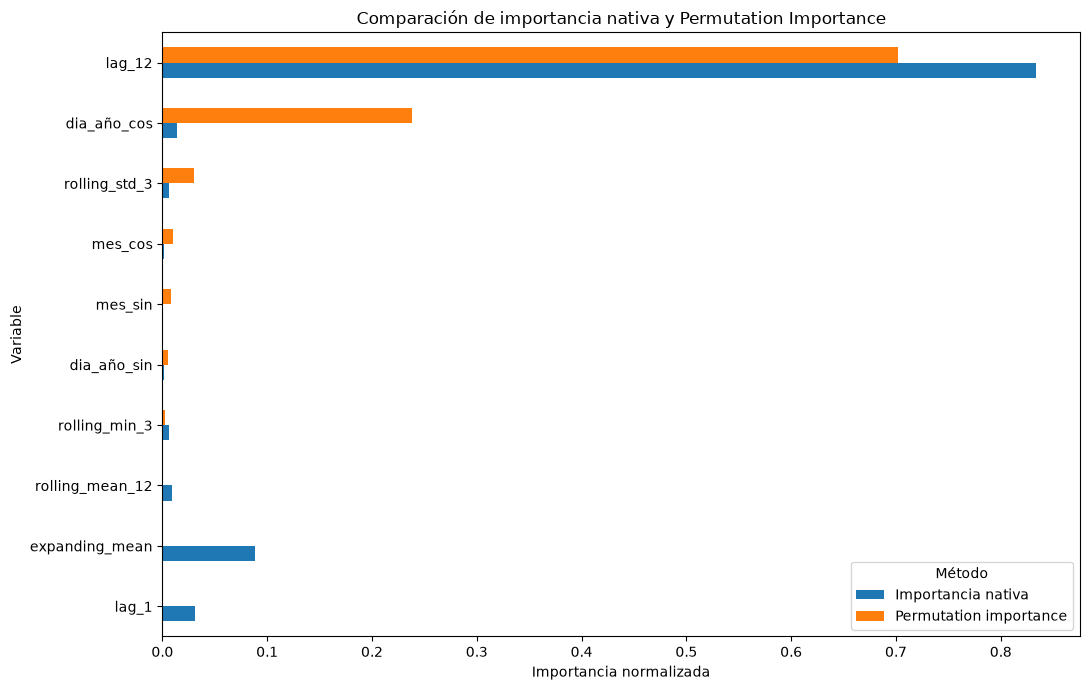

In [51]:
plt.figure(figsize=(11, 7))

comparacion_top.plot(
    kind="barh",
    figsize=(11, 7)
)

plt.title("Comparación de importancia nativa y Permutation Importance")
plt.xlabel("Importancia normalizada")
plt.ylabel("Variable")
plt.legend(title="Método")
plt.tight_layout()
plt.show()

¿Cuál de los dos holdouts refleja mejor el escenario real de uso del modelo (predecir el futuro)? Argumentar en términos de "el cuándo" vs "el qué pasó".

El Holdout temporal. Mezclar el test-train split con shuffle causa que la seccion de entrenamiento tenga "missings" en su serie temporal por lo que entrenara sin ver posibles sectores claves. Al mismo tiempo, puede ver todo el espectro temporal, cuando lo que queremos es limitar el entrenamiento al pasado, para predecir el futuro.

En el holdout temporal, comparar features_fecha vs features_all. ¿Cuánto aporta realmente tener lags/rolling frente a usar solo variables de calendario?

El calculo de top 10 permutation importance revela 2 de los valores "rolling o lag" son del top 3 mas importantes. Por esto y por la gran mejora que hay en el MASE entre un modole con todos lo features vs el otro, podemos interpretar que hay un gran aporte en el tipo de variables que resumen o indican al modelo sucesos anteriores.

Interpretar el valor de MASE en el holdout temporal: ¿el modelo le gana o le pierde al naive estacional? ¿Qué les dice esto sobre la dificultad de mejorar un baseline fuerte en series cortas y muy estacionales?

El holdout temporal pierde contra el naive estacional, tanto con todos los features como solo con las fechas. Si el modelo es una serie corta con mucha estacionalidad, el gradient boosting debera aprender ese patron estacional desde 0, lo cual en una serie corta, es decir pocos datos, es muy dificil.

¿Qué feature domina el ranking en ambas técnicas? ¿Por qué tiene sentido que sea esa, dada la naturaleza estacional de la serie?

Lag_12. Tiene sentido ya que al ser enormente estacional, es decir, tiene un patron repetido año a año, uno puede generar una prediccion muy confiable dando un valor muy parecido al del año anterior teniendo en cuenta los cambios proporcionales del contexto.